# Fashion MNIST classification (Keras)

## Libraries and constants

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import functools

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
from utils import plot_loss_acc_per_ep, seed_everything

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data import

Fashion MNIST dataset positioned as a substitute for the usual numerical MNIST, which is too simple.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

## Data Overview

In [4]:
print("\nTrain set: ")
print(X_train.shape)
print(y_train.shape)

print("\nTest set: ")
print(X_test.shape)
print(y_test.shape)


Train set: 
(60000, 28, 28)
(60000,)

Test set: 
(10000, 28, 28)
(10000,)


There are only 3 dimensions (num_images, height, width, 1 color channel) - the images are grayscale.

In [5]:
print(type(X_train[0]))
print(np.unique(X_train))

<class 'numpy.ndarray'>
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 24

Each image is a numpy array, unnormalized

In [6]:
def plot_random_mnist_fashion_images(x_data: np.ndarray, y_data: np.ndarray, num_images: int, rng: np.random.Generator):
    # 1. sample images with replace=False (without replacement) from a uniform distribution
    random_indices = rng.choice(len(x_data), size=num_images, replace=False)

    # 2. process the data
    np_imgs = x_data[random_indices].copy().astype(np.uint8)    # PIL Image expects uint8
    np_labels = y_data[random_indices].copy()

    # 3. plot
    plt.figure(figsize=(24, 6))
    for i in range(num_images):
        img = Image.fromarray(np_imgs[i], mode="L")             # to PIL grayscale image
        label = np_labels[i]

        plt.subplot(
                1,              # a number of rows to plot on
                num_images,     # a number of columns
                i + 1,          # current position to plot in
            )
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

Train images:


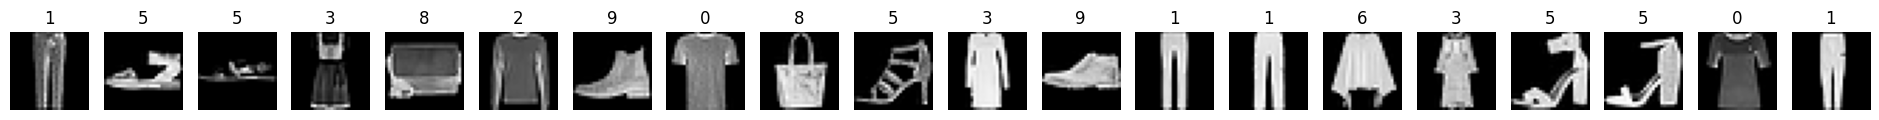

Test images:


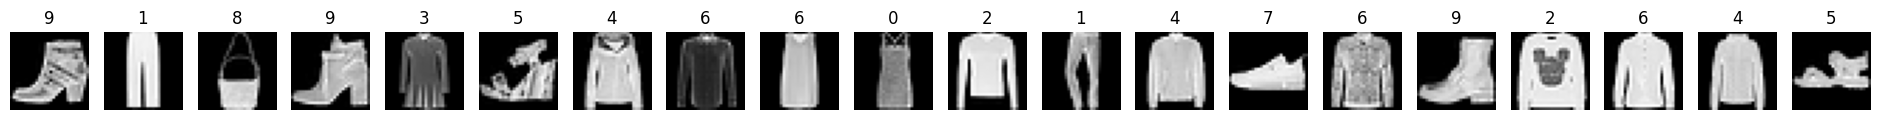

In [7]:
print("Train images:")
plot_random_mnist_fashion_images(X_train, y_train, 20, rng)

print("Test images:")
plot_random_mnist_fashion_images(X_test, y_test, 20, rng)

In [8]:
print(f"Train targets: {np.unique(y_train)}")
print(f"Test targets: {np.unique(y_test)}")

Train targets: [0 1 2 3 4 5 6 7 8 9]
Test targets: [0 1 2 3 4 5 6 7 8 9]


Each image represents a fashion item 28x28. The target labels are 10 categorical integers (0-9). Present classes based on the [docs](https://github.com/zalandoresearch/fashion-mnist): 
- 0:    T-shirt/top
- 1:	Trouser
- 2:	Pullover
- 3:	Dress
- 4:	Coat
- 5:	Sandal
- 6:	Shirt
- 7:	Sneaker
- 8:	Bag
- 9:	Ankle boot

### Class balance

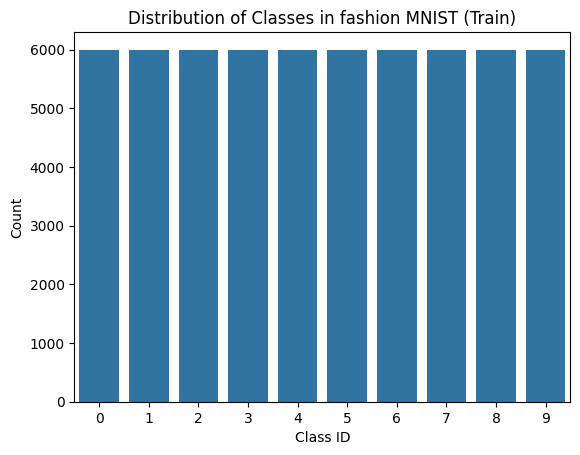

In [9]:
sns.countplot(x=y_train)
plt.title("Distribution of Classes in fashion MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [10]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

The train set is perfectly distributed. No imbalance concerns.

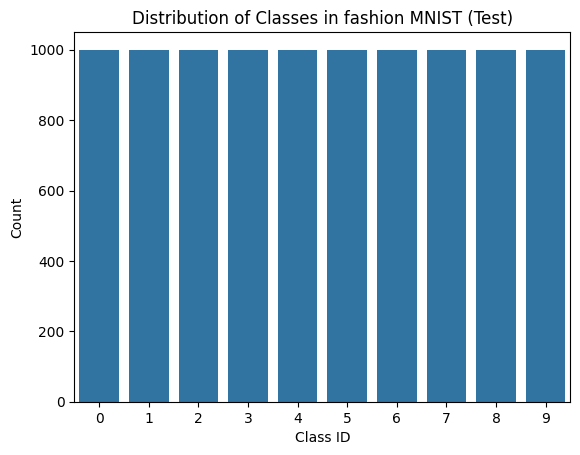

In [11]:
sns.countplot(x=y_test)
plt.title("Distribution of Classes in fashion MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [12]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000],
       dtype=int64))

The test set is perfectly distributed. No imbalance concerns.

### Data representation, data split

The dataset is light and easy, but if we were to face a real problem with huge data that doesn't fit RAM, we would have to move away from `np.arrays` completely. We're going to go for the real approach.

In [13]:
class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()      # pixels are floats to be able to normalize later
        self.targets = torch.from_numpy(targets).clone().int()  # class labels are integers (0-9)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target


# for simple data we could just:
# torch_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))

`X_train` from `keras.datasets.fashion_mnist.load_data()` is read-only and it's specified in the object's numpy metadata. We copy it to allocate new memory and create a new object.

In [14]:
X_train_writable = X_train.copy()
y_train_writable = y_train.copy()

In [ ]:
full_train_ds  = FashionMNISTDataset(X_train_writable, y_train_writable)
test_ds  = FashionMNISTDataset(X_test, y_test)

# Split train into train/validation (90/10)
train_size = int(0.9 * len(X_train))
val_size = len(full_train_ds) - train_size

train_ds, valid_ds = random_split(
    dataset=full_train_ds,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_9396\2467506895.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  self.targets = torch.from_numpy(targets).clone().int()  # class labels are integers (0-9)


In [16]:
print(f"Train: {len(train_ds)}, Validation: {len(valid_ds)}, Test: {len(test_ds)}")

Train: 54000, Validation: 6000, Test: 10000


Confirming everything's intact.

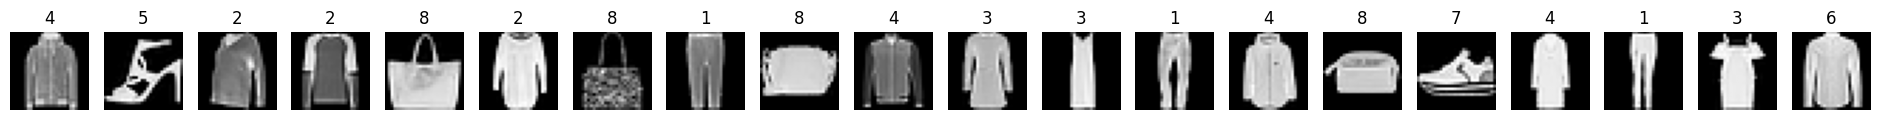

In [17]:
plot_random_mnist_fashion_images(full_train_ds.data.numpy(), full_train_ds.targets.numpy(), 20, rng)

In [18]:
img, label = train_ds[0]
print(img.shape, label)

torch.Size([28, 28]) tensor(9, dtype=torch.int32)


## Creating and testing loaders

In [19]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(valid_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [20]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([9, 3, 3,  ..., 3, 6, 6], dtype=torch.int32)


## EDA

### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

In [21]:
# (60000, 28, 28) -> (60000, 784)
train_images_2d = X_train.reshape(-1, 784)

print(f"mnist_train_array_2d.shape = {train_images_2d.shape}")

mnist_train_array_2d.shape = (60000, 784)


In [22]:
# ---------- STEP 1: Fit ----------
iso = IsolationForest(
    n_estimators=500,           # number of random trees
    contamination=0.01,         # expect ~1% anomalies
    max_samples='auto',         # subsample size per tree
    random_state=RANDOM_SEED,
)

iso.fit(train_images_2d)

,n_estimators,500
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [23]:
# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) ----------
flags = iso.predict(train_images_2d)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

Train anomalies flagged: 600


In [24]:
# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(train_images_2d)
print("Top 5 lowest (most anomalous) scores:", sorted(anomaly_score)[:5])

Top 5 lowest (most anomalous) scores: [-0.6934106527099005, -0.6659250893274931, -0.6656201525195374, -0.6626475185657702, -0.662274318689953]


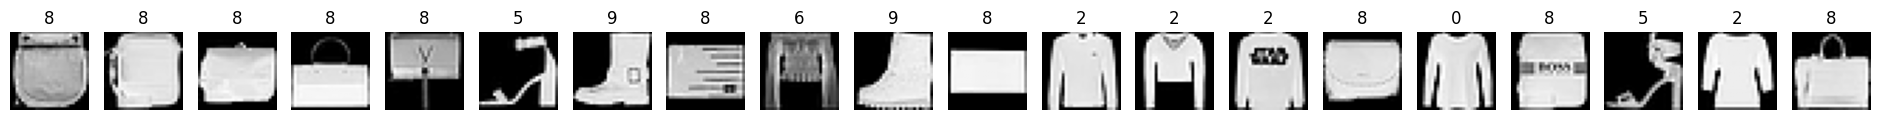

In [25]:
# ---------- STEP 4: See the flagged images ----------
outlier_idx = np.where(flags == -1)[0]
outliers_mnist_train = np.array([X_train[idx] for idx in outlier_idx])
outlier_targets = np.array([y_train[idx] for idx in outlier_idx])

plot_random_mnist_fashion_images(outliers_mnist_train, outlier_targets, 20, rng)

All items are recognizable, some corners are cut **slightly**, even in the worst-flagged images. No outliers present. To fully confirm we do indeed have only the 10 mentioned classes (the dataset is a reliable source, but we are performing a real-world sanity check), we'd have to obtain more data. There's not enough evidence to state "no side objects present" as if the nature of the false-mnist image pixels is similar to our data's, Isolation Forest can't discern them.

We cannot mathematically prove there are exactly $0$ out-of-class items in a $60,000$-image dataset unless we look at all $60,000$. Instead, we must define a tiny acceptable error threshold. For data science, a standard threshold is fewer than $1\%$ of the data being corrupted/out-of-class. We are going to use Acceptance Sampling.

**The goal**: We want to be $95\%$ confident that the out-of-class rate in the dataset is under $1\%$.
$H_0$: The dataset **DOES** contain unrelated images. The proportion of unrelated images $p ≥ 0.01$
$H_1$: The dataset **DOES NOT** contain unrelated images. The proportion of unrelated images $p < 0.01$.

If the true rate of bad images is $1\%$ ($0.01$), then the probability of a randomly picked image being *correct* (fashion) is $99\%$ ($0.99$) each. For a sample size of $n$, the probability of picking $n$ correct images in a row is the product (1st AND 2nd AND 3rd ...): $$p = (0.99)^n \leftarrow \text{Probability of 0 defects}$$
Now, we demand based on the condition and solve:

$$\begin{gather*}
(0.99)^n \le 0.05 \\ \\
\text{Solving for $n$ using logarithms:} \\
\ln(0.99)^n \le \ln(0.05) \\
n \cdot \ln(0.99) \le \ln(0.05) \\
n \ge \frac{\ln(0.05)}{\ln(0.99)} \\ \\
\text{Plug in the values:} \\
n \ge \frac{-2.9957}{-0.01005} \approx 298.07 
\end{gather*}$$

*Decision*: To prove with $95\%$ confidence that the dataset has less than $1\%$ unrelated images, we must **randomly sample and inspect $299$ images**. 
- If we find $0$ unrelated images, we reject $H_0$ and may state with $95\%$ confidence that the overall defect rate is $< 1\%$.
- If we find even $1$ unrelated image, we fail to reject $H_0$ and therefore cannot guarantee that the defect rate is below $1\%$.

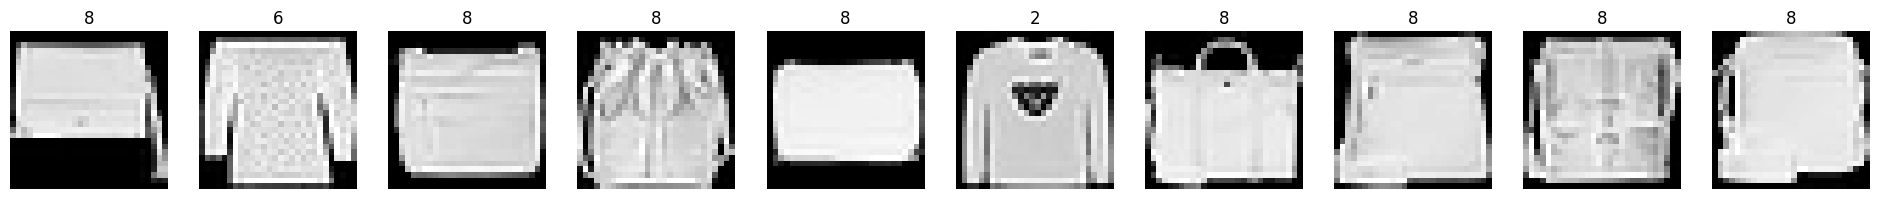

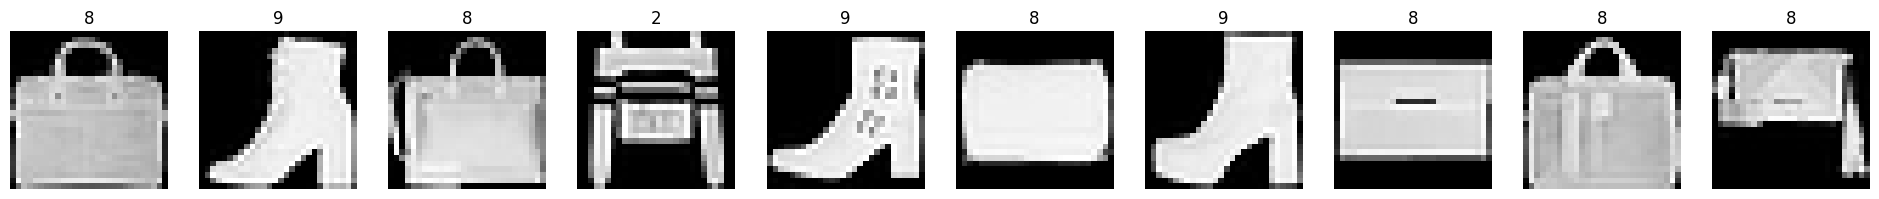

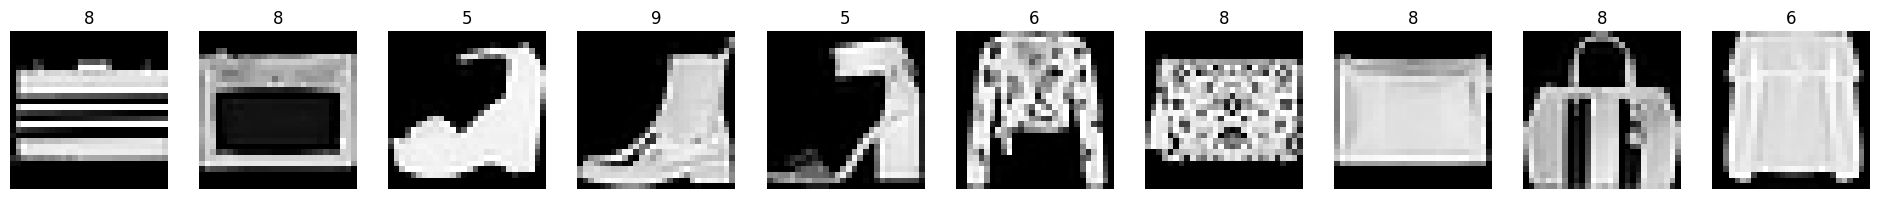

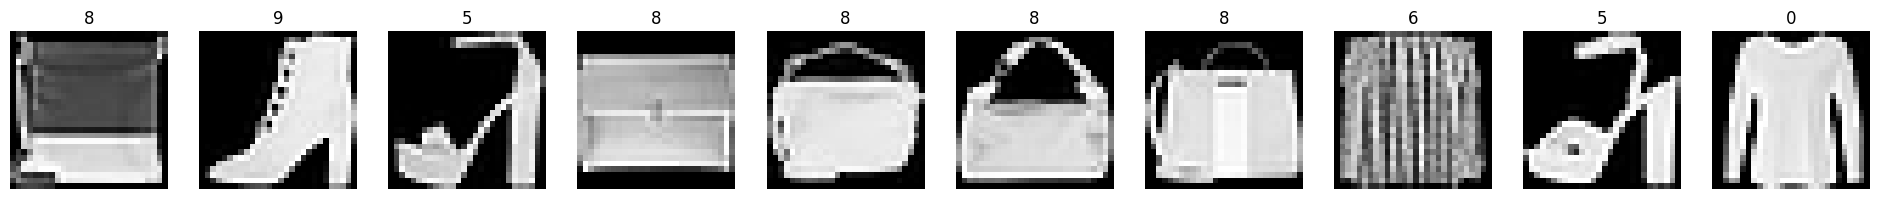

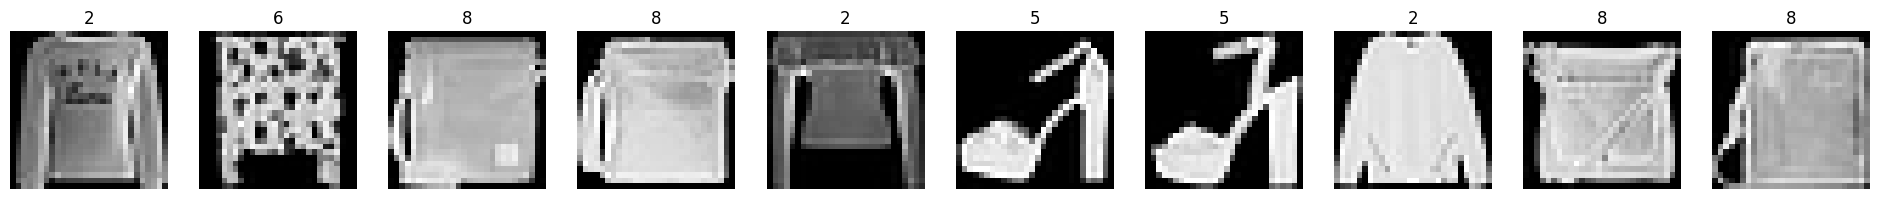

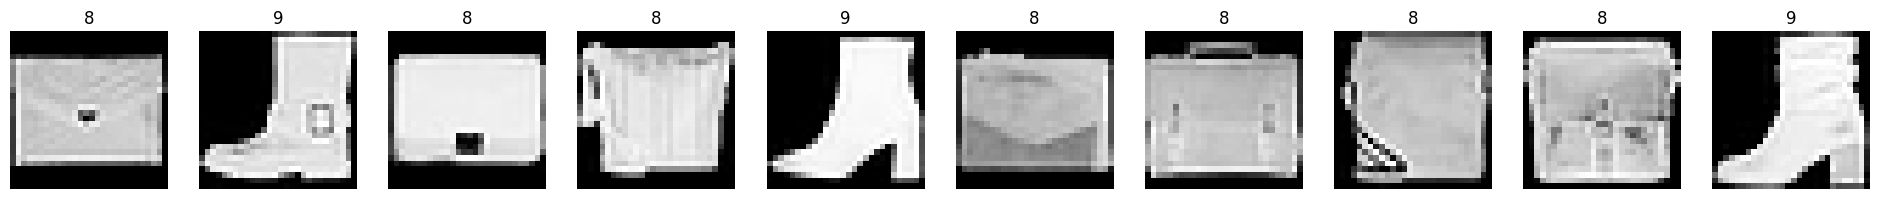

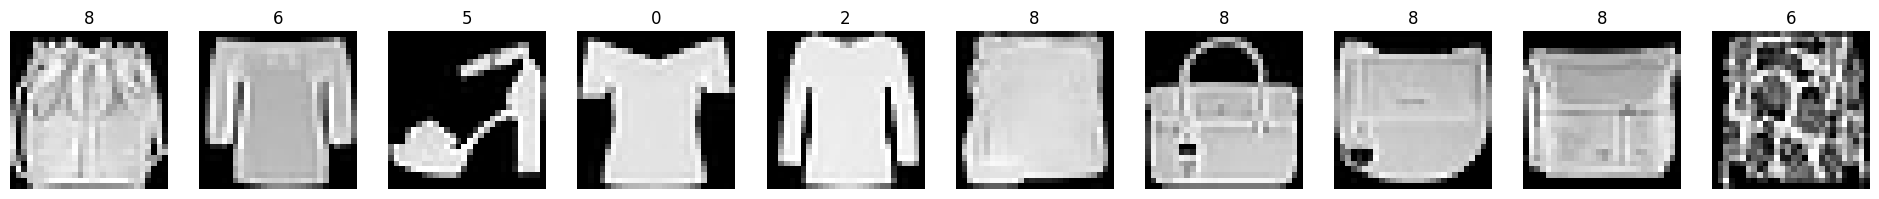

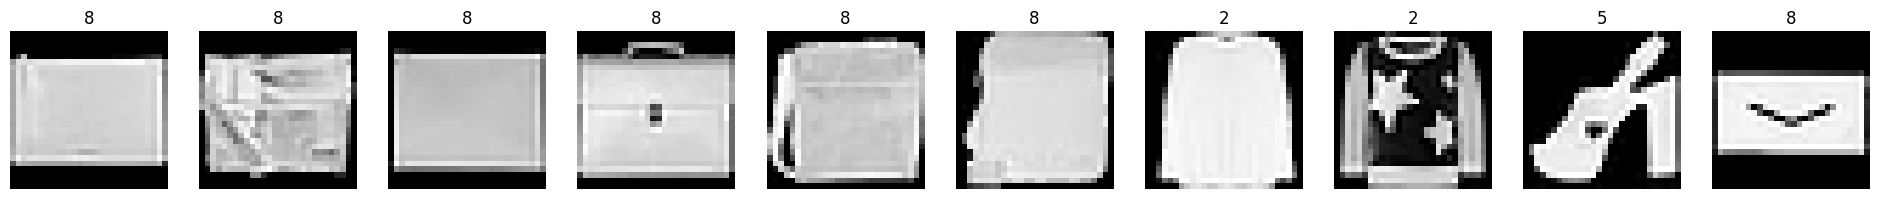

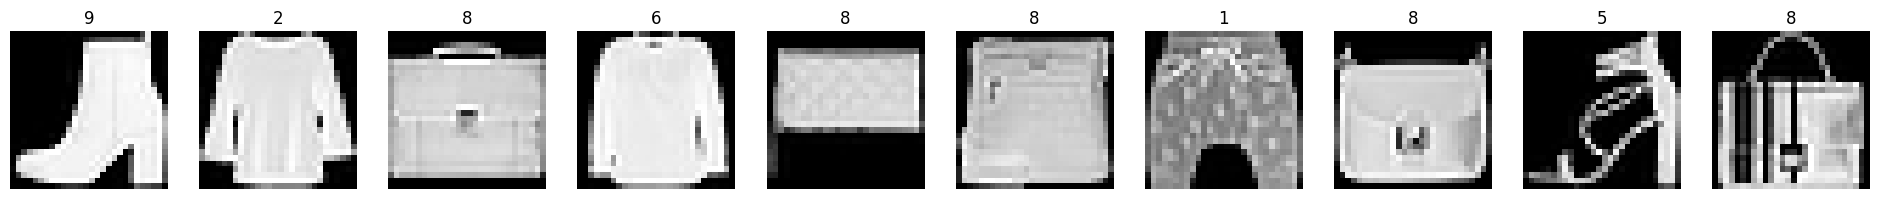

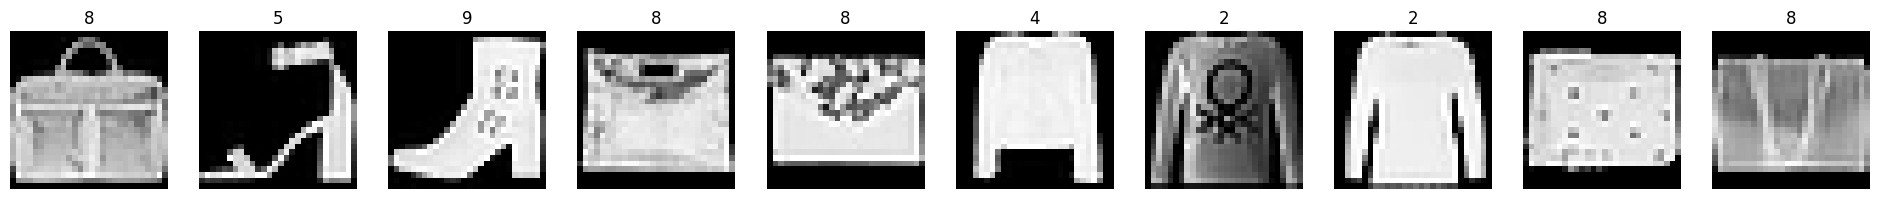

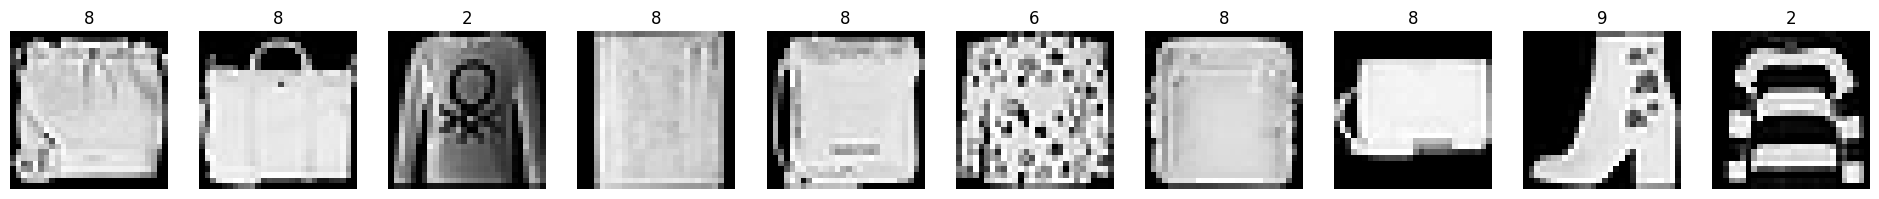

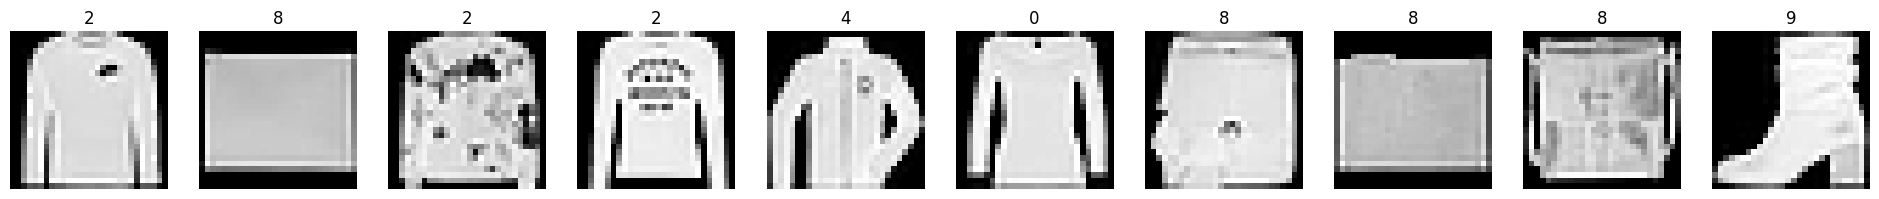

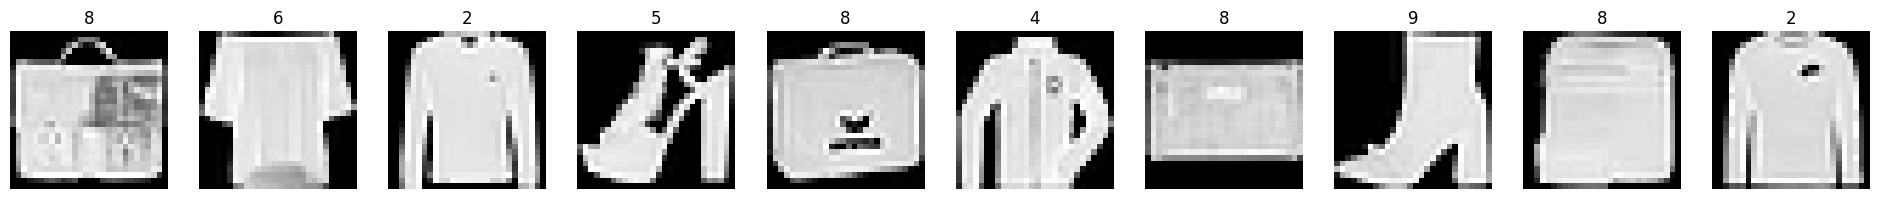

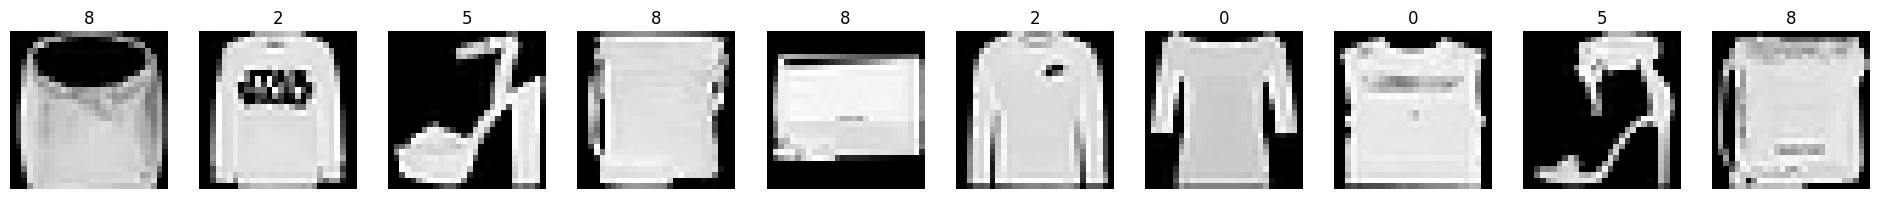

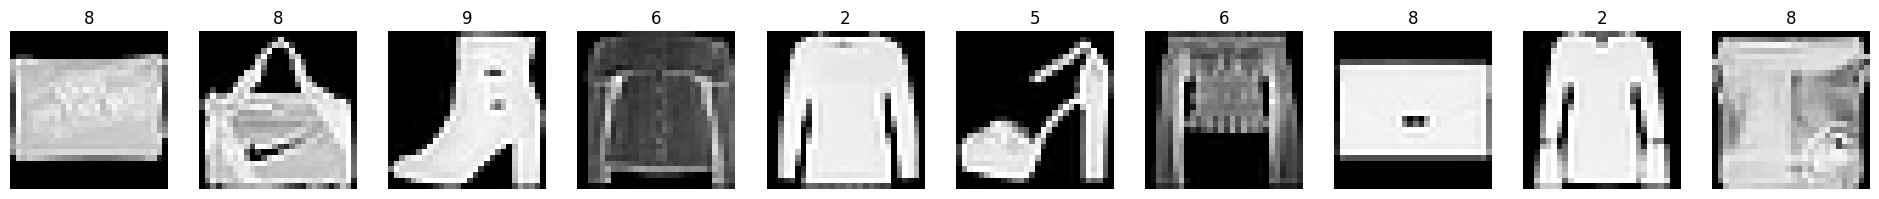

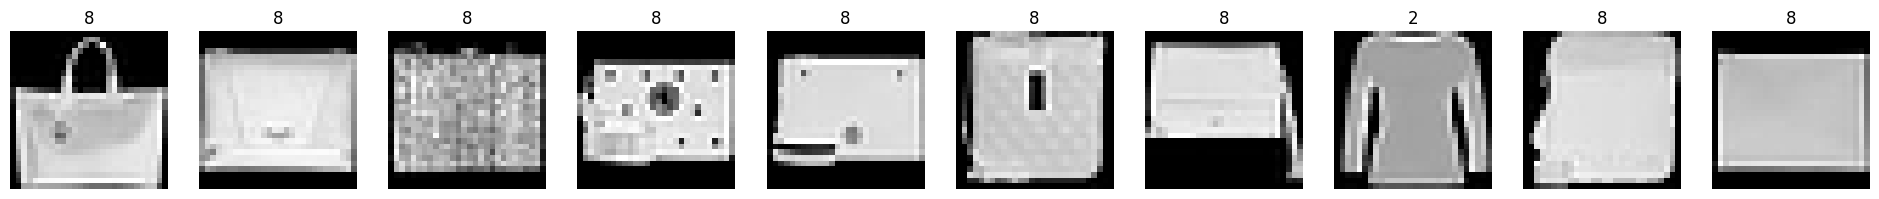

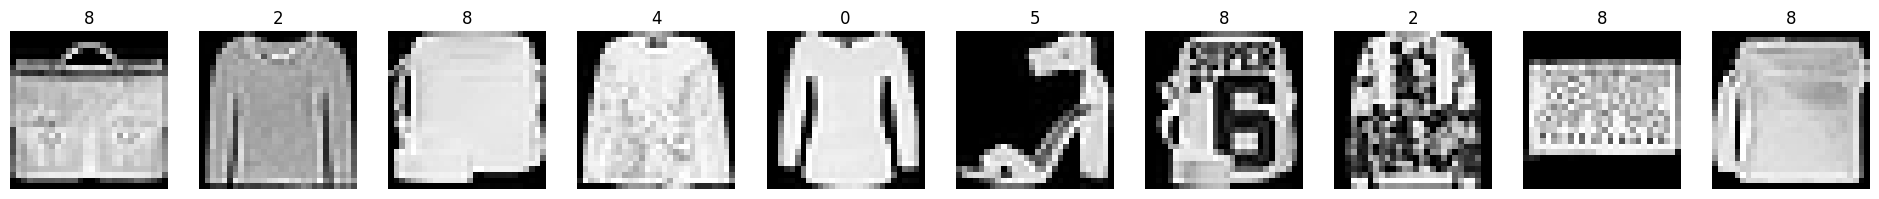

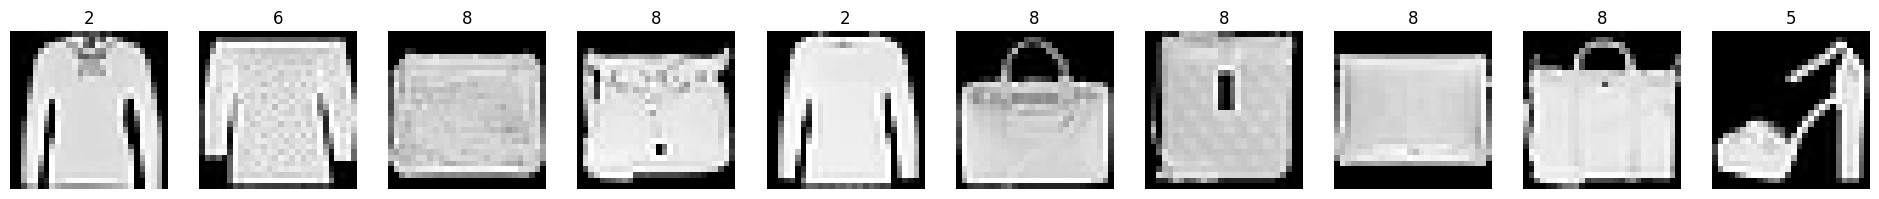

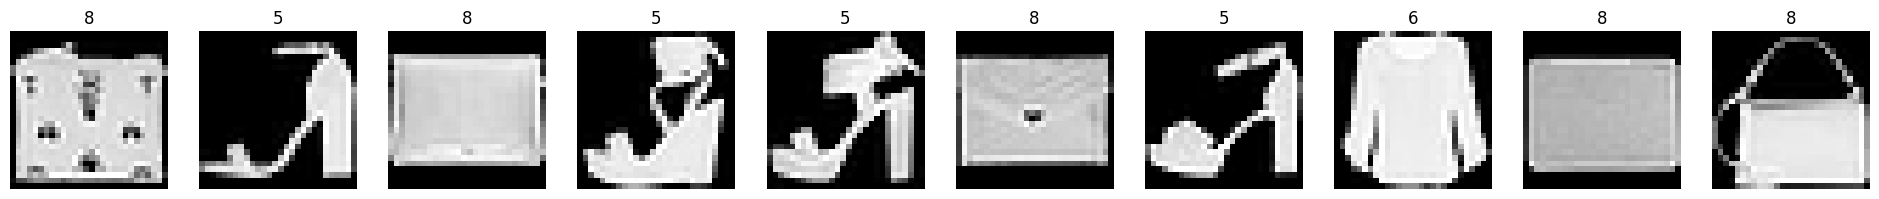

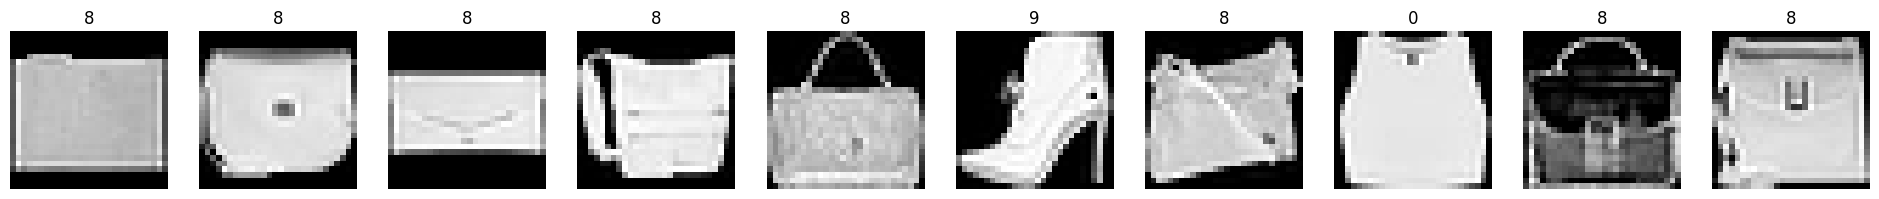

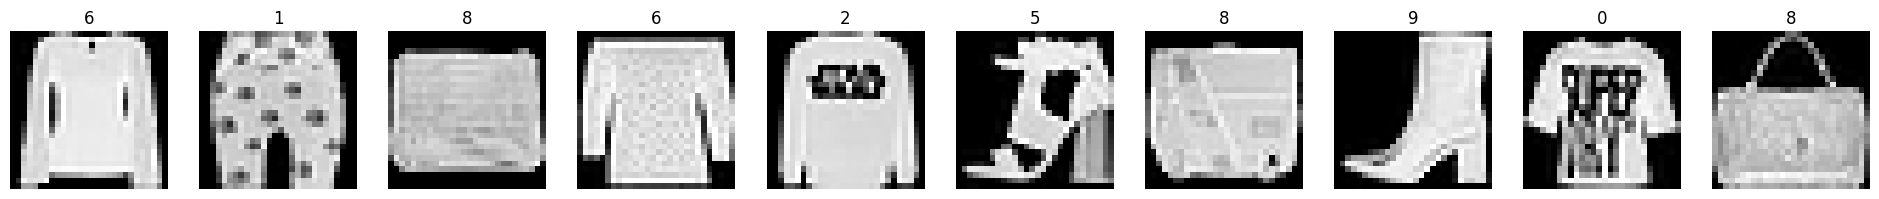

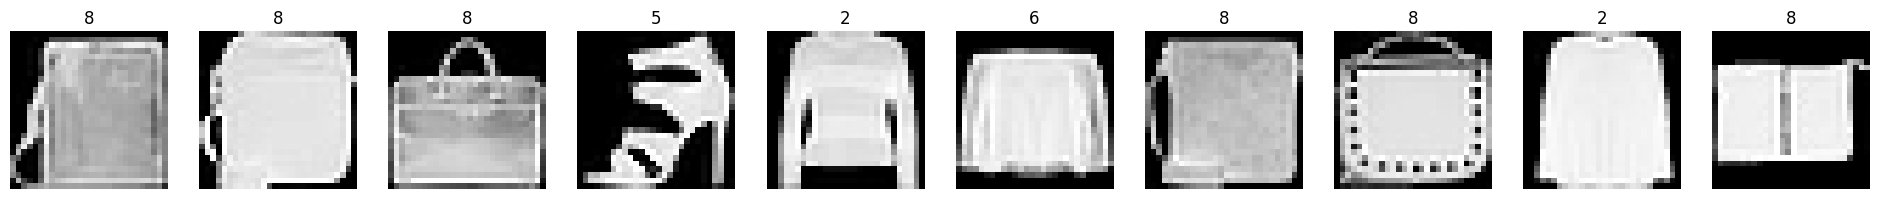

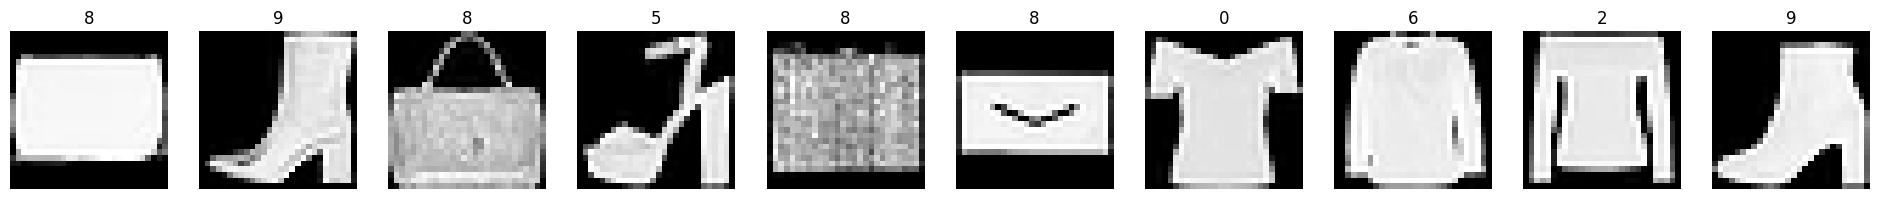

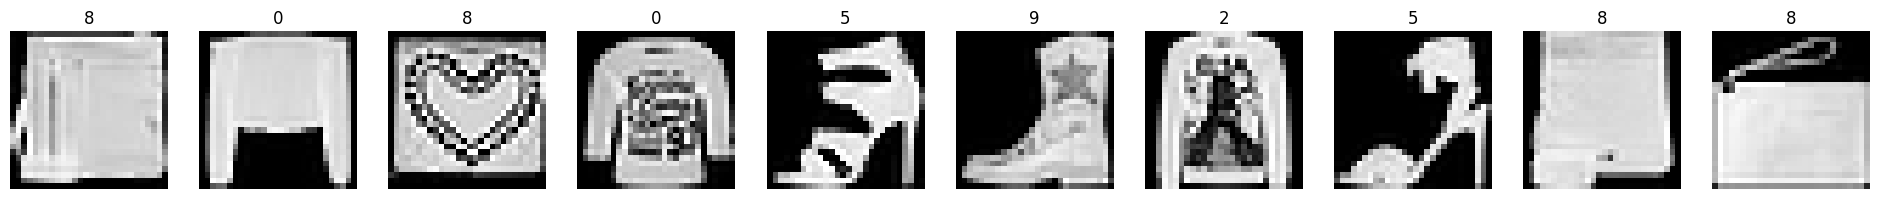

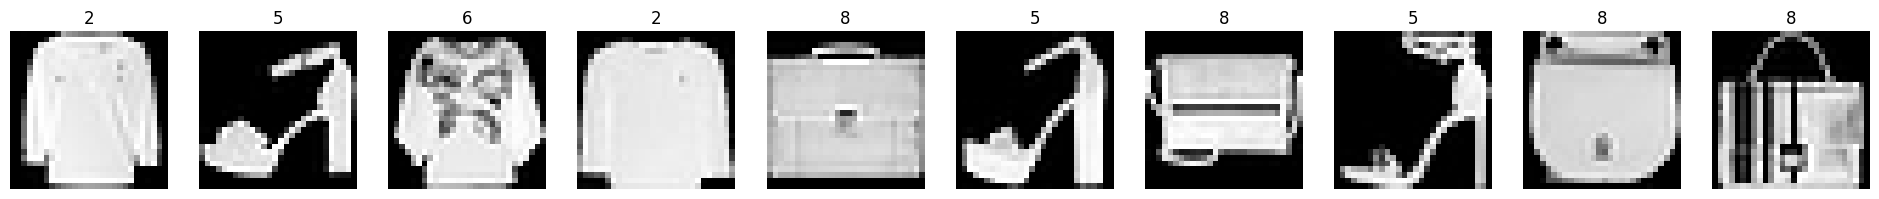

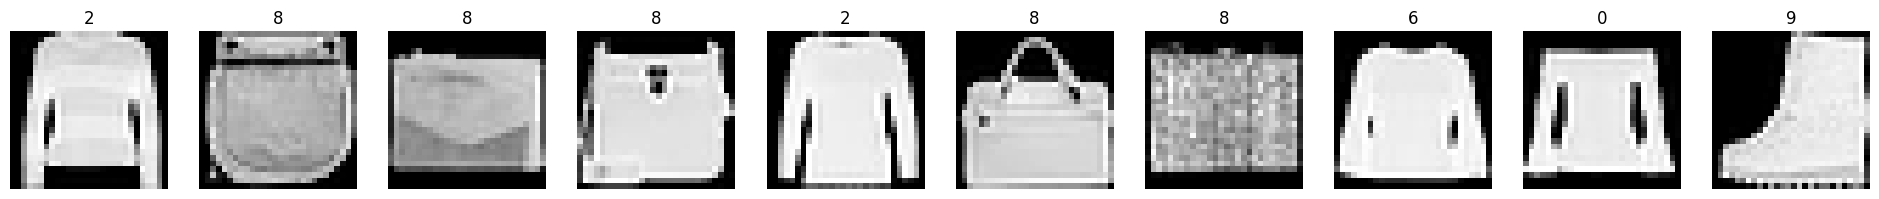

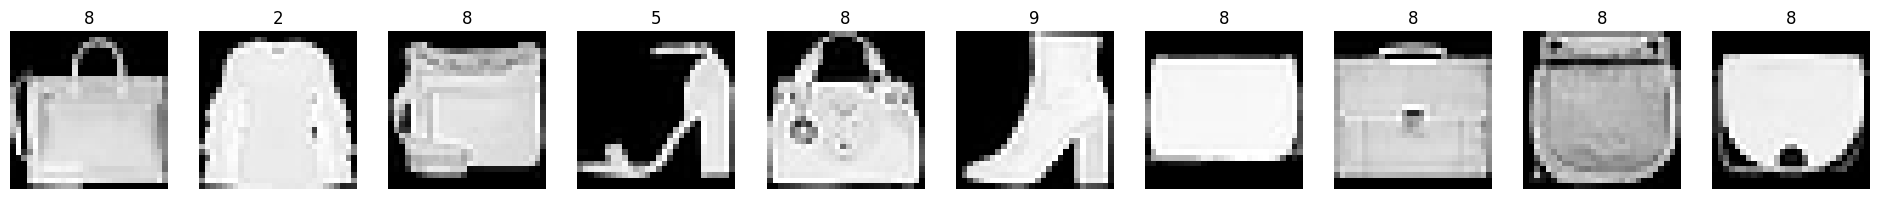

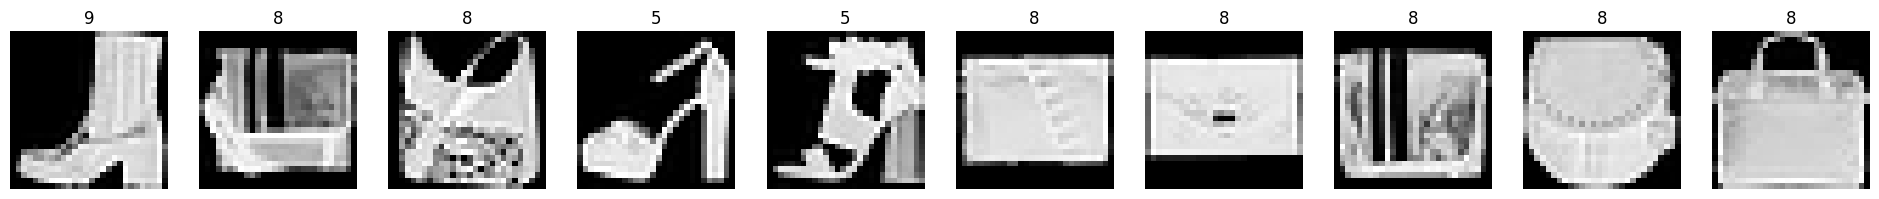

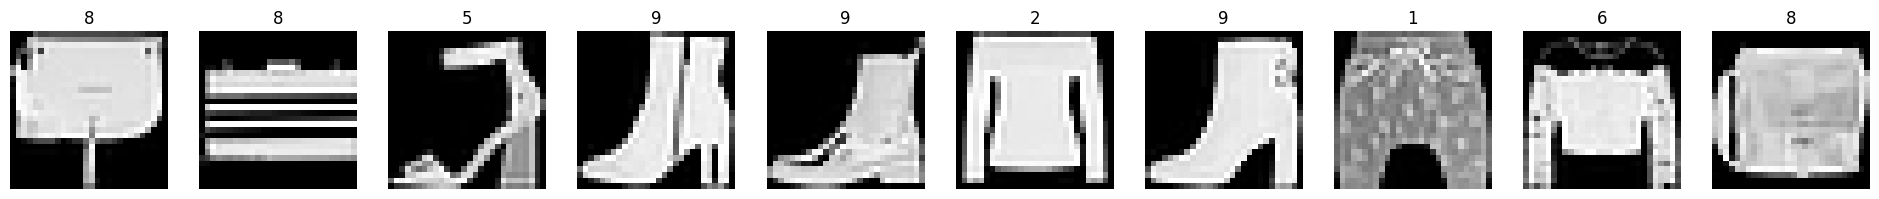

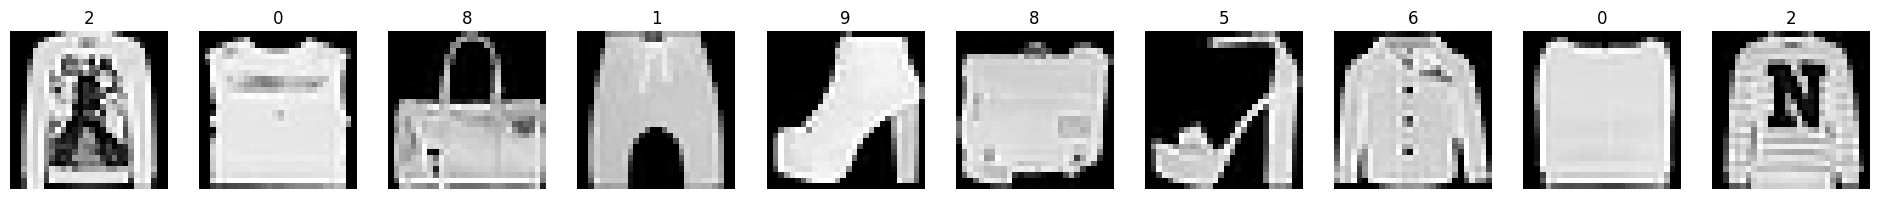

In [28]:
sample_idx = rng.choice(len(X_train), size=299, replace=False)   # uniform, distinct, from the FULL set

for _ in range(30):
    plot_random_mnist_fashion_images(outliers_mnist_train, outlier_targets, 10, rng)

In [ ]:
# k = number of out-of-class items we counted by eye
k = 0

print("p-value:", stats.binom.cdf(k, 299, 0.01))

p-value: 0.049536256637662486


No out-of-class images found. The $H_0$ rejected, $p < 0.05$.

## Model, metrics and hyperparameter selection

Based on the fact that the task is a literal substitute for standard MNIST, we presume minimal complexity is necessary. We are going to utilize the same FFN network, just adding `Dropout` with low probability for educational purposes.

As for the metrics, we choose `accuracy` because the set is perfectly balanced, planning to conclude using the full classification report.

For the loss function - `cross-entropy` - the undisputed, industry-wide mathematical standard for multiclass classification.

Optimizer - `Adam` - also industry standard with relatively high learning rate of `1e-3`. We will be tunning with other optimizers as well. 

This is a strong baseline.

In [36]:
model = keras.Sequential([
    # Explicitly define the input shape as its own layer object (best practice)
    keras.layers.Input(shape=(28, 28)),
    #normalizer,
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Data normalization

As always, for the sake of speeding up the convergence, stabilize GD, eliminating brightness  biases, we normalize the pixel data to $[0,1]$, then standardize features to a sample mean of $\mu=0$ and sample standard deviation of $s=0$.

In order to do that, we need the whole dataset, which in this case is not huge and fits RAM. But the best practice is to import it in batches in case there are too many samples.

While importing, we're summing the sums and elements to later calculate final dataset's mean and std to use them for z-normalization.

In [31]:
# Calculate the whole dataset's mean and std
n = 0; s = 0.0; ss = 0.0
for x, _ in train_loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()

mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5
variance_ds = std_ds ** 2

# Hardcode the stats into Keras
normalizer = keras.layers.Normalization(
    axis=None,
    mean=mean_ds,
    variance=variance_ds,
)

The model now:

In [33]:
def build_baseline_model(num_units=128, dropout=0.1, lr=1e-3, activation="relu", random_seed: int = 42):
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
        keras.layers.Dense(num_units, activation=activation),
        keras.layers.Dropout(dropout, seed=random_seed),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

## Training

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)      # seeds python/numpy/torch/keras in one call
torch_gen.manual_seed(RANDOM_SEED)            # rewind the generator's state

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
model = build_baseline_model(num_units=128, dropout=0.1, lr=1e-3, activation="relu", random_seed=RANDOM_SEED)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8168 - loss: 0.5165 - val_accuracy: 0.8562 - val_loss: 0.3923
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8630 - loss: 0.3752 - val_accuracy: 0.8672 - val_loss: 0.3697
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8746 - loss: 0.3424 - val_accuracy: 0.8752 - val_loss: 0.3520
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8828 - loss: 0.3211 - val_accuracy: 0.8787 - val_loss: 0.3380
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8889 - loss: 0.3010 - val_accuracy: 0.8765 - val_loss: 0.3415
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8932 - loss: 0.2866 - val_accuracy: 0.8823 - val_loss: 0.3265
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8968 - loss: 0.2761 - val_accuracy: 0.8848 - val_loss: 0.3159
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9028 - loss: 0.2639 - val_accu

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.5165  val_loss=0.3923  train_acc=0.8168  val_acc=0.8562
Epoch  2: train_loss=0.3752  val_loss=0.3697  train_acc=0.8630  val_acc=0.8672
Epoch  3: train_loss=0.3424  val_loss=0.3520  train_acc=0.8746  val_acc=0.8752
Epoch  4: train_loss=0.3211  val_loss=0.3380  train_acc=0.8828  val_acc=0.8787
Epoch  5: train_loss=0.3010  val_loss=0.3415  train_acc=0.8889  val_acc=0.8765
Epoch  6: train_loss=0.2866  val_loss=0.3265  train_acc=0.8932  val_acc=0.8823
Epoch  7: train_loss=0.2761  val_loss=0.3159  train_acc=0.8968  val_acc=0.8848
Epoch  8: train_loss=0.2639  val_loss=0.3186  train_acc=0.9028  val_acc=0.8870
Epoch  9: train_loss=0.2569  val_loss=0.3329  train_acc=0.9052  val_acc=0.8817
Epoch 10: train_loss=0.2485  val_loss=0.3116  train_acc=0.9075  val_acc=0.8860
Epoch 11: train_loss=0.2406  val_loss=0.3224  train_acc=0.9101  val_acc=0.8873
Epoch 12: train_loss=0.2295  val_loss=0.3169  train_acc=0.9139  val_acc=0.8880
Epoch 1

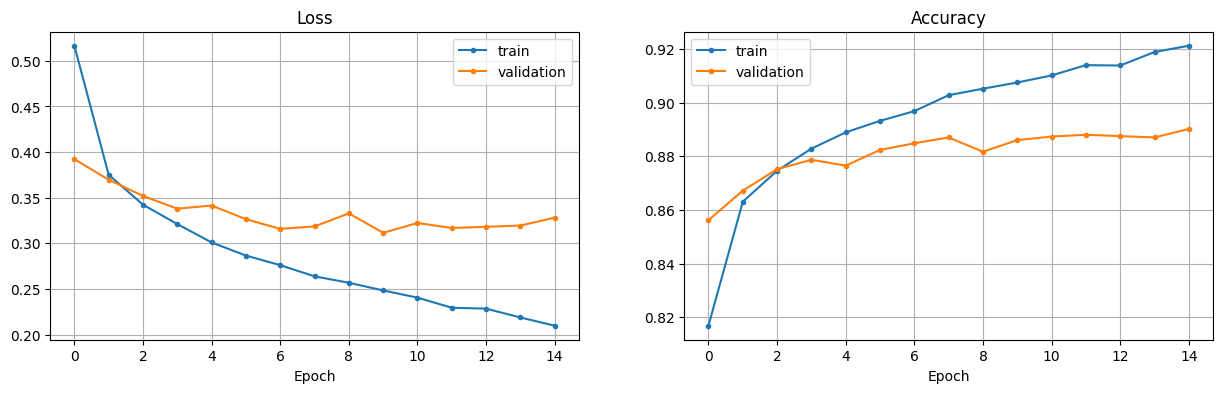

In [39]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Baseline best:

| Epoch (Best) | Batch Size | Optimizer, LR          | Train Loss | Val Loss | Train Acc | Val Acc |
| :---:        | :---:      | :---:                  | :---:      | :---:    | :---:     | :---:   |
| 4            | 125        | Adam(1e-3)             | 0.3211     | 0.3380   | 0.8828    | 0.8787  |

Looks like it might need a LR scheduler since after arriving near the minimum it might be taking too aggressive leaps forward.

**Strategy**: before applying LR schedulers, shrink the parameter space with keras tuner gradually.

In [29]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256
    activation = hp.Choice("activation", ["relu", "tanh", "elu"])       # relu,tanh,elu
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # 0.0,0.1,0.2,0.3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation=activation))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

Overall number of combination to try currently: $3 \times 4 \times 3 \times 4 \times 4 \times 3=1728$

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,               # keyword, not positional
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 01m 17s]
val_accuracy: 0.8833333253860474

Best val_accuracy So Far: 0.8918333053588867
Total elapsed time: 00h 16m 45s
{'num_layers': 1, 'units': 256, 'activation': 'elu', 'dropout': 0.2, 'lr': 0.001, 'optimizer': 'adam'}


In [ ]:
def debug_tuner(tuner):
    trial_list = []

    # Loop through all trials stored in the tuner's oracle
    for trial_id, trial in tuner.oracle.trials.items():
        row = {
            "trial_id": trial_id,
            "score": trial.score,  # This will be your val_accuracy or val_loss
        }
        # Unpack and add the specific hyperparameters chosen for this trial
        row.update(trial.hyperparameters.values)
        trial_list.append(row)

    # Convert to DataFrame
    df_results = pd.DataFrame(trial_list)

    # Sort them so the best-performing models are at the top
    # (Change ascending=True if you are optimizing for loss instead of accuracy)
    df_results = df_results.sort_values(by="score", ascending=False)

    # Display the neat table!
    return df_results

In [80]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,activation,dropout,lr,optimizer
9,09,0.891833,1,256,elu,0.2,0.0010,adam
11,11,0.888500,1,256,elu,0.0,0.0010,rmsprop
4,04,0.886500,1,128,elu,0.1,0.0005,rmsprop
13,13,0.885167,2,64,elu,0.1,0.0010,adam
6,06,0.885000,3,64,elu,0.0,0.0005,adam
14,14,0.883333,2,128,tanh,0.2,0.0010,adam
1,01,0.882833,3,64,elu,0.0,0.0010,adam
10,10,0.882333,1,128,elu,0.2,0.0005,adam
3,03,0.878000,1,64,elu,0.2,0.0050,adam
0,00,0.877500,2,64,tanh,0.0,0.0050,sgd


Most of the time, the prevalent parameters among the best scores are: Adam, elu. It is seen clearly. Holding these constant, we've reduced the number of combinations to: $3 \times 4 \times 4 \times 4 = 192$.

In [ ]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # 0.0,0.1,0.2,0.3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation="elu"))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 01m 10s]
val_accuracy: 0.8865000009536743

Best val_accuracy So Far: 0.8934999704360962
Total elapsed time: 00h 17m 57s
{'num_layers': 3, 'units': 128, 'dropout': 0.0, 'lr': 0.0005}


In [83]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,dropout,lr
7,07,0.893500,3,128,0.0,0.0005
5,05,0.888833,3,128,0.1,0.0005
4,04,0.886500,2,64,0.0,0.0005
14,14,0.886500,2,128,0.0,0.0010
9,09,0.885167,3,64,0.0,0.0010
0,00,0.885000,2,64,0.1,0.0005
2,02,0.884500,2,64,0.2,0.0010
6,06,0.883500,1,64,0.2,0.0010
13,13,0.877833,2,256,0.1,0.0001
1,01,0.876667,3,128,0.1,0.0001


Regularization tends to be 0.0 to 0.1 for the best results, the lr of 0.0001 has never made it to the top, shrinking further by leaving these two behind makes it to $3 \times 4 \times 2 \times 3=72$ params.

In [ ]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256
    dropout = hp.Float("dropout", 0.0, 0.1, step=0.1)                   # 0.0,0.1

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation="elu"))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 00m 53s]
val_accuracy: 0.8851666450500488

Best val_accuracy So Far: 0.8946666717529297
Total elapsed time: 00h 15m 08s
{'num_layers': 2, 'units': 256, 'dropout': 0.0, 'lr': 0.0005}


In [32]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,dropout,lr
13,13,0.894667,2,256,0.0,0.0005
7,07,0.893500,3,128,0.0,0.0005
5,05,0.893000,3,128,0.0,0.0010
2,02,0.888000,2,64,0.1,0.0010
11,11,0.887500,3,64,0.0,0.0005
4,04,0.887333,2,64,0.0,0.0010
1,01,0.886333,3,128,0.1,0.0005
10,10,0.885833,1,128,0.1,0.0005
9,09,0.885167,3,64,0.0,0.0010
14,14,0.885167,2,128,0.0,0.0010


Dropout has clearly set at 0.0, layers > 1. Total combinations at this point: $2 \times 4  \times 3=24$.

In [ ]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=2, max_value=3)         # 2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation="elu"))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=24,                      # all remaining combinations
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 23 Complete [00h 01m 00s]
val_accuracy: 0.8943333625793457

Best val_accuracy So Far: 0.8995000123977661
Total elapsed time: 00h 21m 58s
{'num_layers': 2, 'units': 192, 'lr': 0.001}


In [43]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,lr
20,20,0.899500,2,192,0.0010
7,07,0.899167,3,256,0.0005
3,03,0.894500,2,192,0.0005
22,22,0.894333,3,128,0.0010
21,21,0.893333,3,192,0.0010
5,05,0.892167,2,128,0.0010
1,01,0.892000,2,256,0.0010
9,09,0.891333,2,128,0.0005
13,13,0.890667,3,192,0.0005
16,16,0.890000,2,256,0.0005


Based on the best results, we stick to 2 layers 192 units each and proceed to fine-tuning.

## Fine-tuning

In [ ]:
# established model after thorough tuning with keras tuner
def build_model(lr=1e-3):
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

Training the best model so far to look at the learning curves:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
model = build_model(lr=1e-3)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8289 - loss: 0.4752 - val_accuracy: 0.8487 - val_loss: 0.4080
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8710 - loss: 0.3498 - val_accuracy: 0.8735 - val_loss: 0.3529
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8843 - loss: 0.3138 - val_accuracy: 0.8792 - val_loss: 0.3368
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8902 - loss: 0.2899 - val_accuracy: 0.8717 - val_loss: 0.3447
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9018 - loss: 0.2655 - val_accuracy: 0.8750 - val_loss: 0.3478
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9068 - loss: 0.2487 - val_accuracy: 0.8857 - val_loss: 0.3144
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9115 - loss: 0.2340 - val_accuracy: 0.8827 - val_loss: 0.3336
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9172 - loss: 0.2187 - val_accu

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.4752  val_loss=0.4080  train_acc=0.8289  val_acc=0.8487
Epoch  2: train_loss=0.3498  val_loss=0.3529  train_acc=0.8710  val_acc=0.8735
Epoch  3: train_loss=0.3138  val_loss=0.3368  train_acc=0.8843  val_acc=0.8792
Epoch  4: train_loss=0.2899  val_loss=0.3447  train_acc=0.8902  val_acc=0.8717
Epoch  5: train_loss=0.2655  val_loss=0.3478  train_acc=0.9018  val_acc=0.8750
Epoch  6: train_loss=0.2487  val_loss=0.3144  train_acc=0.9068  val_acc=0.8857
Epoch  7: train_loss=0.2340  val_loss=0.3336  train_acc=0.9115  val_acc=0.8827
Epoch  8: train_loss=0.2187  val_loss=0.3096  train_acc=0.9172  val_acc=0.8947
Epoch  9: train_loss=0.2067  val_loss=0.3486  train_acc=0.9212  val_acc=0.8828
Epoch 10: train_loss=0.1952  val_loss=0.3206  train_acc=0.9262  val_acc=0.8910
Epoch 11: train_loss=0.1866  val_loss=0.3404  train_acc=0.9288  val_acc=0.8898
Epoch 12: train_loss=0.1735  val_loss=0.3287  train_acc=0.9338  val_acc=0.8923
Epoch 1

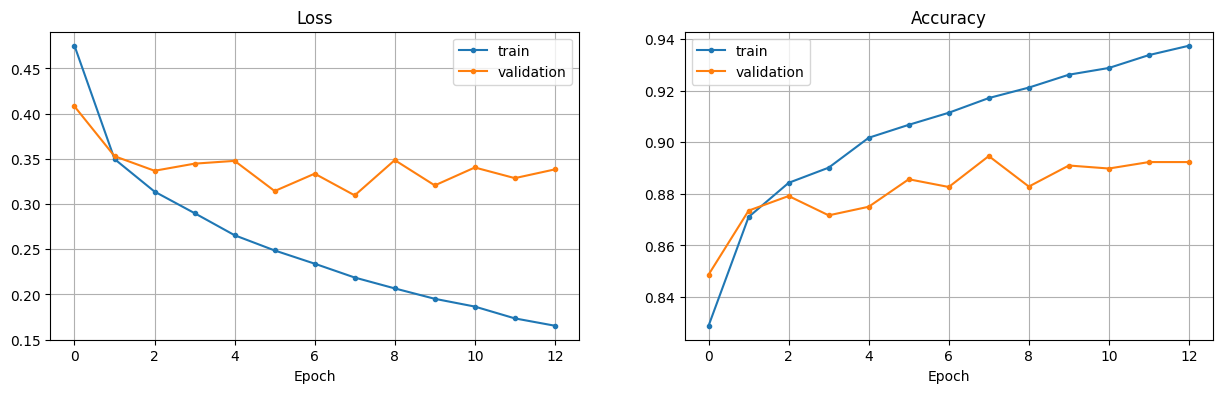

In [50]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Experimenting with batch size. Since it converges in early epochs (3) and starts overfitting/get stuck, we want more generalization -> increasing batch size $125 \rightarrow 250$:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)      # seeds python/numpy/torch/keras in one call
torch_gen.manual_seed(RANDOM_SEED)            # rewind the generator's state

train_loader, valid_loader = build_loaders(batch_size=250, shuffle=True, generator=torch_gen)
model = build_model(lr=1e-3)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8224 - loss: 0.4993 - val_accuracy: 0.8502 - val_loss: 0.4135
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8690 - loss: 0.3590 - val_accuracy: 0.8673 - val_loss: 0.3776
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8801 - loss: 0.3244 - val_accuracy: 0.8787 - val_loss: 0.3493
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8898 - loss: 0.2980 - val_accuracy: 0.8778 - val_loss: 0.3254
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8978 - loss: 0.2776 - val_accuracy: 0.8688 - val_loss: 0.3532
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9036 - loss: 0.2599 - val_accuracy: 0.8827 - val_loss: 0.3290
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9082 - loss: 0.2452 - val_accuracy: 0.8838 - val_loss: 0.3175
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9156 - loss: 0.2259 - val_accu

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.4993  val_loss=0.4135  train_acc=0.8224  val_acc=0.8502
Epoch  2: train_loss=0.3590  val_loss=0.3776  train_acc=0.8690  val_acc=0.8673
Epoch  3: train_loss=0.3244  val_loss=0.3493  train_acc=0.8801  val_acc=0.8787
Epoch  4: train_loss=0.2980  val_loss=0.3254  train_acc=0.8898  val_acc=0.8778
Epoch  5: train_loss=0.2776  val_loss=0.3532  train_acc=0.8978  val_acc=0.8688
Epoch  6: train_loss=0.2599  val_loss=0.3290  train_acc=0.9036  val_acc=0.8827
Epoch  7: train_loss=0.2452  val_loss=0.3175  train_acc=0.9082  val_acc=0.8838
Epoch  8: train_loss=0.2259  val_loss=0.3192  train_acc=0.9156  val_acc=0.8857
Epoch  9: train_loss=0.2181  val_loss=0.3295  train_acc=0.9184  val_acc=0.8837
Epoch 10: train_loss=0.2073  val_loss=0.2992  train_acc=0.9209  val_acc=0.8923
Epoch 11: train_loss=0.1966  val_loss=0.3326  train_acc=0.9266  val_acc=0.8852
Epoch 12: train_loss=0.1839  val_loss=0.3213  train_acc=0.9312  val_acc=0.8880
Epoch 1

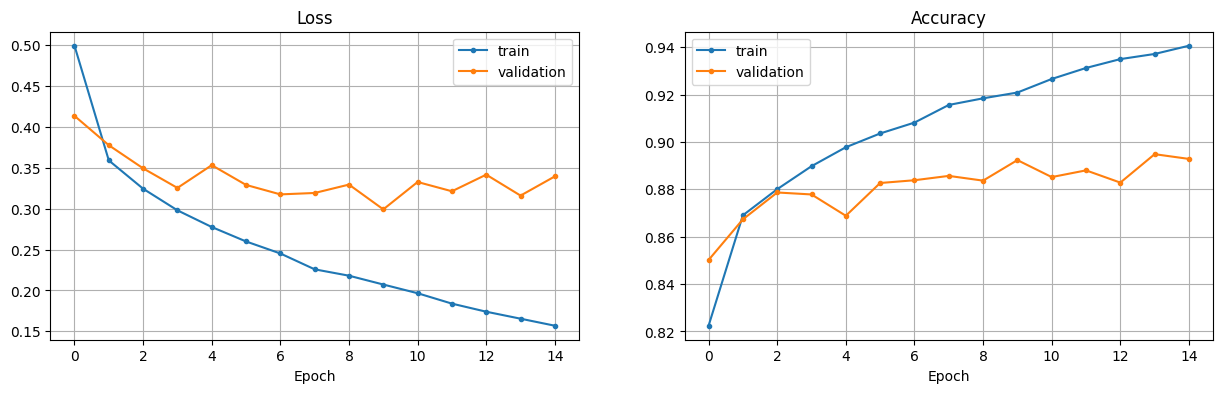

In [52]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

The 3rd is still the best, but the scores are worst. Didn't take more epochs. Therefore, it's been more likely just oscillating around minimum. Trying the lower the batch size just to confirm the hypothesis:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=75, shuffle=True, generator=torch_gen)
model = build_model(lr=1e-3)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8319 - loss: 0.4639 - val_accuracy: 0.8632 - val_loss: 0.3691
Epoch 2/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8709 - loss: 0.3494 - val_accuracy: 0.8722 - val_loss: 0.3618
Epoch 3/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8845 - loss: 0.3100 - val_accuracy: 0.8722 - val_loss: 0.3569
Epoch 4/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8933 - loss: 0.2827 - val_accuracy: 0.8755 - val_loss: 0.3340
Epoch 5/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9013 - loss: 0.2620 - val_accuracy: 0.8788 - val_loss: 0.3486
Epoch 6/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9075 - loss: 0.2457 - val_accuracy: 0.8883 - val_loss: 0.3220
Epoch 7/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9134 - loss: 0.2293 - val_accuracy: 0.8900 - val_loss: 0.3263
Epoch 8/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9189 - loss: 0.2143 - val_accu

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.4639  val_loss=0.3691  train_acc=0.8319  val_acc=0.8632
Epoch  2: train_loss=0.3494  val_loss=0.3618  train_acc=0.8709  val_acc=0.8722
Epoch  3: train_loss=0.3100  val_loss=0.3569  train_acc=0.8845  val_acc=0.8722
Epoch  4: train_loss=0.2827  val_loss=0.3340  train_acc=0.8933  val_acc=0.8755
Epoch  5: train_loss=0.2620  val_loss=0.3486  train_acc=0.9013  val_acc=0.8788
Epoch  6: train_loss=0.2457  val_loss=0.3220  train_acc=0.9075  val_acc=0.8883
Epoch  7: train_loss=0.2293  val_loss=0.3263  train_acc=0.9134  val_acc=0.8900
Epoch  8: train_loss=0.2143  val_loss=0.3223  train_acc=0.9189  val_acc=0.8913
Epoch  9: train_loss=0.2037  val_loss=0.3742  train_acc=0.9216  val_acc=0.8753
Epoch 10: train_loss=0.1909  val_loss=0.3177  train_acc=0.9267  val_acc=0.8933
Epoch 11: train_loss=0.1787  val_loss=0.3429  train_acc=0.9315  val_acc=0.8938
Epoch 12: train_loss=0.1705  val_loss=0.3306  train_acc=0.9349  val_acc=0.8910
Epoch 1

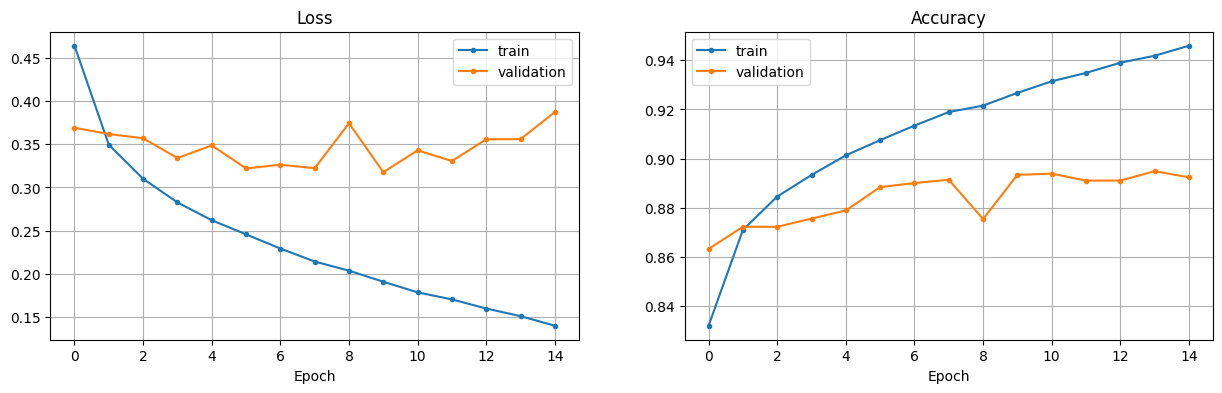

In [55]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Hypothesis confirmed. `batch_size` = $125$ established. 

The last thing is to resolve the oscillation trying to converge using lr schedulers.

In [ ]:
# custom arbitrary scheduler with large staircase jumps
def scheduler(epoch, lr):
    # epochs starts to be indexed with 0, so I added "-1" for intuition
    if epoch > 10-1:
        lr = 1e-6
    elif epoch > 7-1:
        lr = 1e-5
    elif epoch > 3-1:
        lr = 1e-4

    return lr

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
model = build_model(lr=1e-3)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.LearningRateScheduler(scheduler, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8289 - loss: 0.4752 - val_accuracy: 0.8487 - val_loss: 0.4080 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8710 - loss: 0.3498 - val_accuracy: 0.8735 - val_loss: 0.3529 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8843 - loss: 0.3138 - val_accuracy: 0.8792 - val_loss: 0.3368 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0001.
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9090 - loss: 0.2466 - val_accuracy: 0.8903 - val_loss: 0.2976 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0001.
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accurac

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.4752  val_loss=0.4080  train_acc=0.8289  val_acc=0.8487
Epoch  2: train_loss=0.3498  val_loss=0.3529  train_acc=0.8710  val_acc=0.8735
Epoch  3: train_loss=0.3138  val_loss=0.3368  train_acc=0.8843  val_acc=0.8792
Epoch  4: train_loss=0.2466  val_loss=0.2976  train_acc=0.9090  val_acc=0.8903
Epoch  5: train_loss=0.2362  val_loss=0.2946  train_acc=0.9132  val_acc=0.8920
Epoch  6: train_loss=0.2305  val_loss=0.2967  train_acc=0.9156  val_acc=0.8932
Epoch  7: train_loss=0.2257  val_loss=0.2959  train_acc=0.9170  val_acc=0.8917
Epoch  8: train_loss=0.2162  val_loss=0.2881  train_acc=0.9215  val_acc=0.8968
Epoch  9: train_loss=0.2143  val_loss=0.2876  train_acc=0.9218  val_acc=0.8963
Epoch 10: train_loss=0.2136  val_loss=0.2880  train_acc=0.9225  val_acc=0.8968
Epoch 11: train_loss=0.2123  val_loss=0.2876  train_acc=0.9227  val_acc=0.8970
Epoch 12: train_loss=0.2122  val_loss=0.2874  train_acc=0.9229  val_acc=0.8977
Epoch 1

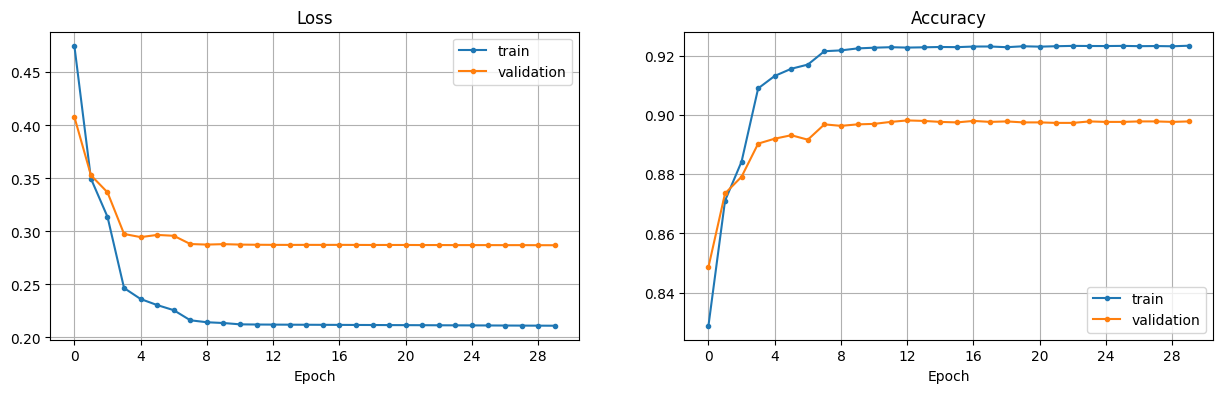

In [62]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

The model has clearly stuck again (the staircase might be to aggressive for Adam) having reached its peak at min loss and max accuracy at the 8th epoch. This is our new best scores:
```
train_loss=0.2162  val_loss=0.2881  train_acc=0.9215  val_acc=0.8968
```

Trying some standard gentler learning rate schedulers to explore possible surfaces.

In [ ]:
def build_rand_search_model(hp, epochs):
    name = hp.Choice("scheduler", [
            "constant",          # baseline: flat 1e-3, for comparison
            "custom_stairs",     # custom staircase: 1e-3 -> 1e-4 @3 -> 1e-5 @7 -> 1e-6 @10
            "exponential",       # smooth *0.9 per epoch
            "cosine",            # glide 1e-3 -> ~0 over the whole run
            "cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            "inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 8, /100 at 16
        ])

    base  = 1e-3
    steps = len(train_loader)          # batches per epoch = 54000/125 = 432
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 3, steps * 7, steps * 10],
                                      values=[base, 1e-4, 1e-5, 1e-6])
    elif name == "exponential":
        lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    elif name == "cosine":
        lr = S.CosineDecay(base, decay_steps=steps * epochs)
    elif name == "cosine_restarts":
        lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 10)
    elif name == "inverse_time":
        lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 8, steps * 16],
                                      values=[base, base * 0.1, base * 0.01])
    else: # "constant"
        lr = base

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=60),   # more epochs + functools to send an additional argument
    objective="val_accuracy",
    directory="tuning",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True,
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=60,   # more epochs
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, # more patience
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)
debug_tuner(sched_tuner)

Trial 7 Complete [00h 01m 50s]
val_accuracy: 0.9039999842643738

Best val_accuracy So Far: 0.9039999842643738
Total elapsed time: 00h 13m 40s


,trial_id,score,scheduler
6,0006,0.904000,piecewise
4,0004,0.900833,cosine_restarts
5,0005,0.900500,inverse_time
0,0000,0.898833,constant
2,0002,0.898833,exponential
1,0001,0.897500,custom_stairs
3,0003,0.893167,cosine


In [ ]:
def build_final_model(lr: float, steps: int):
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(192, activation="elu"),
        keras.layers.Dense(10, activation="softmax"),
    ])

    lr = keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=[steps * 8, steps * 16],
                                      values=[lr, lr * 0.1, lr * 0.01])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
steps = len(train_loader)          # batches per epoch (for lr scheduler)
model = build_final_model(lr=1e-3, steps=steps)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=60,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
        #keras.callbacks.ModelCheckpoint("best.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8289 - loss: 0.4752 - val_accuracy: 0.8487 - val_loss: 0.4080
Epoch 2/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8710 - loss: 0.3498 - val_accuracy: 0.8735 - val_loss: 0.3529
Epoch 3/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8843 - loss: 0.3138 - val_accuracy: 0.8792 - val_loss: 0.3368
Epoch 4/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8902 - loss: 0.2899 - val_accuracy: 0.8717 - val_loss: 0.3447
Epoch 5/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9018 - loss: 0.2655 - val_accuracy: 0.8750 - val_loss: 0.3478
Epoch 6/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9068 - loss: 0.2487 - val_accuracy: 0.8857 - val_loss: 0.3144
Epoch 7/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9115 - loss: 0.2340 - val_accuracy: 0.8827 - val_loss: 0.3336
Epoch 8/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9172 - loss: 0.2187 - val_accu

Smoothed scores over epochs grouped by folds:
Epoch  1: train_loss=0.4752  val_loss=0.4080  train_acc=0.8289  val_acc=0.8487
Epoch  2: train_loss=0.3498  val_loss=0.3529  train_acc=0.8710  val_acc=0.8735
Epoch  3: train_loss=0.3138  val_loss=0.3368  train_acc=0.8843  val_acc=0.8792
Epoch  4: train_loss=0.2899  val_loss=0.3447  train_acc=0.8902  val_acc=0.8717
Epoch  5: train_loss=0.2655  val_loss=0.3478  train_acc=0.9018  val_acc=0.8750
Epoch  6: train_loss=0.2487  val_loss=0.3144  train_acc=0.9068  val_acc=0.8857
Epoch  7: train_loss=0.2340  val_loss=0.3336  train_acc=0.9115  val_acc=0.8827
Epoch  8: train_loss=0.2187  val_loss=0.3096  train_acc=0.9172  val_acc=0.8947
Epoch  9: train_loss=0.1640  val_loss=0.2824  train_acc=0.9396  val_acc=0.9028
Epoch 10: train_loss=0.1530  val_loss=0.2833  train_acc=0.9444  val_acc=0.9042
Epoch 11: train_loss=0.1486  val_loss=0.2850  train_acc=0.9461  val_acc=0.9035
Epoch 12: train_loss=0.1447  val_loss=0.2841  train_acc=0.9471  val_acc=0.9037
Epoch 

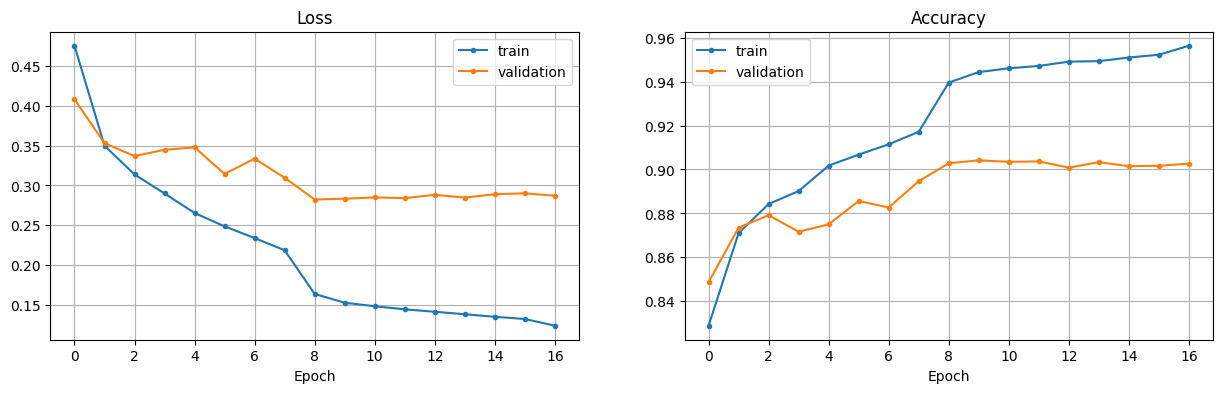

In [36]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Since val loss starts to increase at `epoch 10`, we stop at the `9th` (new best score):
```
Epoch  9: train_loss=0.1640  val_loss=0.2824  train_acc=0.9396  val_acc=0.9028
```

## Best model and evaluation

Training the best model before final evaluation:

In [37]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
steps = len(train_loader)          # batches per epoch (for lr scheduler)
model = build_final_model(lr=1e-3, steps=steps)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=9,
    verbose=1,
    shuffle=False,
)

Epoch 1/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8289 - loss: 0.4752 - val_accuracy: 0.8487 - val_loss: 0.4080
Epoch 2/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8710 - loss: 0.3498 - val_accuracy: 0.8735 - val_loss: 0.3529
Epoch 3/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8843 - loss: 0.3138 - val_accuracy: 0.8792 - val_loss: 0.3368
Epoch 4/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8902 - loss: 0.2899 - val_accuracy: 0.8717 - val_loss: 0.3447
Epoch 5/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9018 - loss: 0.2655 - val_accuracy: 0.8750 - val_loss: 0.3478
Epoch 6/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9068 - loss: 0.2487 - val_accuracy: 0.8857 - val_loss: 0.3144
Epoch 7/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9115 - loss: 0.2340 - val_accuracy: 0.8827 - val_loss: 0.3336
Epoch 8/9
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9172 - loss: 0.2187 - val_accuracy: 0.

Smoothed scores over epochs grouped by folds:
Epoch  1: train_loss=0.4752  val_loss=0.4080  train_acc=0.8289  val_acc=0.8487
Epoch  2: train_loss=0.3498  val_loss=0.3529  train_acc=0.8710  val_acc=0.8735
Epoch  3: train_loss=0.3138  val_loss=0.3368  train_acc=0.8843  val_acc=0.8792
Epoch  4: train_loss=0.2899  val_loss=0.3447  train_acc=0.8902  val_acc=0.8717
Epoch  5: train_loss=0.2655  val_loss=0.3478  train_acc=0.9018  val_acc=0.8750
Epoch  6: train_loss=0.2487  val_loss=0.3144  train_acc=0.9068  val_acc=0.8857
Epoch  7: train_loss=0.2340  val_loss=0.3336  train_acc=0.9115  val_acc=0.8827
Epoch  8: train_loss=0.2187  val_loss=0.3096  train_acc=0.9172  val_acc=0.8947
Epoch  9: train_loss=0.1640  val_loss=0.2824  train_acc=0.9396  val_acc=0.9028



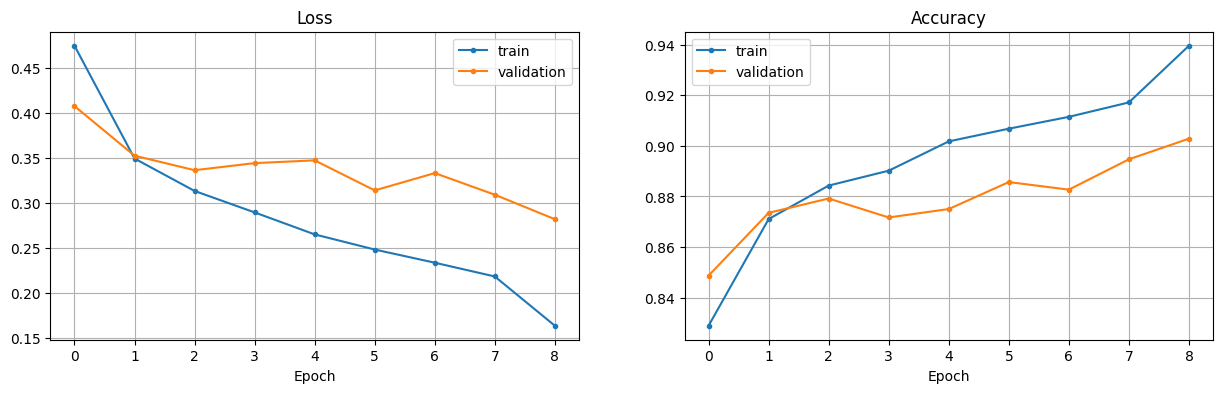

In [38]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Fit on full train first:

In [40]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

full_train_loader = DataLoader(full_train_ds, batch_size=125, shuffle=True, generator=torch_gen)
steps = len(full_train_loader)          # batches per epoch (for lr scheduler)
model = build_final_model(lr=1e-3, steps=steps)

history = model.fit(
    x=full_train_loader,
    epochs=9,
    verbose=1,
    shuffle=False,
)

Epoch 1/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8270 - loss: 0.4740
Epoch 2/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8731 - loss: 0.3458
Epoch 3/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8851 - loss: 0.3092
Epoch 4/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8930 - loss: 0.2846
Epoch 5/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9013 - loss: 0.2633
Epoch 6/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9099 - loss: 0.2433
Epoch 7/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9123 - loss: 0.2331
Epoch 8/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9165 - loss: 0.2179
Epoch 9/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9409 - loss: 0.1621


Smoothed scores over epochs grouped by folds:



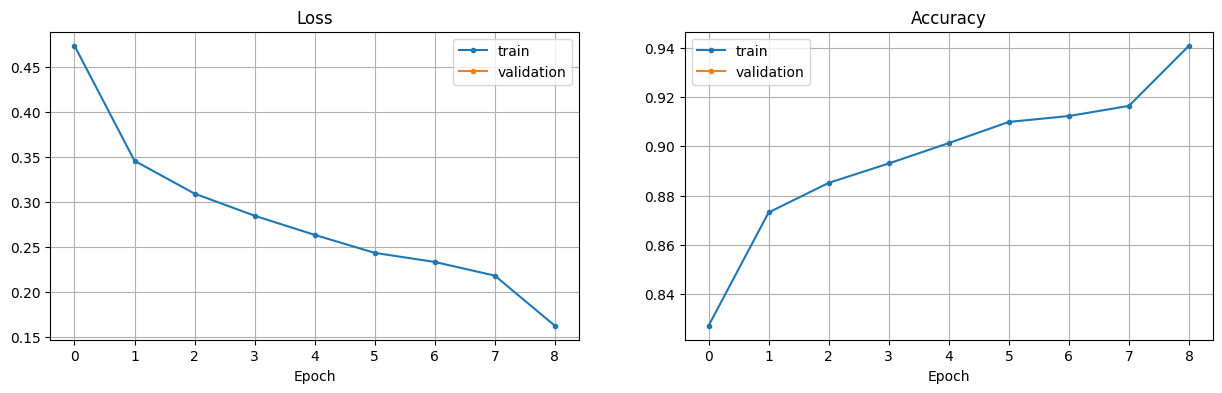

In [41]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

Evaluate on the test loader:

In [42]:
test_loss, test_acc = model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8976 - loss: 0.2997

FINAL TEST ACCURACY: 89.76%
FINAL TEST LOSS:     0.2997


The gap between best validation (`0.903`) and test on full train (`0.8976`) is minimal confirming successful generalization.

              precision    recall  f1-score   support

 T-shirt/top     0.8353    0.8620    0.8484      1000
     Trouser     0.9879    0.9780    0.9829      1000
    Pullover     0.8182    0.8280    0.8231      1000
       Dress     0.9100    0.9000    0.9050      1000
        Coat     0.8190    0.8370    0.8279      1000
      Sandal     0.9736    0.9600    0.9668      1000
       Shirt     0.7487    0.7120    0.7299      1000
     Sneaker     0.9448    0.9590    0.9519      1000
         Bag     0.9769    0.9740    0.9755      1000
  Ankle boot     0.9602    0.9660    0.9631      1000

    accuracy                         0.8976     10000
   macro avg     0.8975    0.8976    0.8974     10000
weighted avg     0.8975    0.8976    0.8974     10000



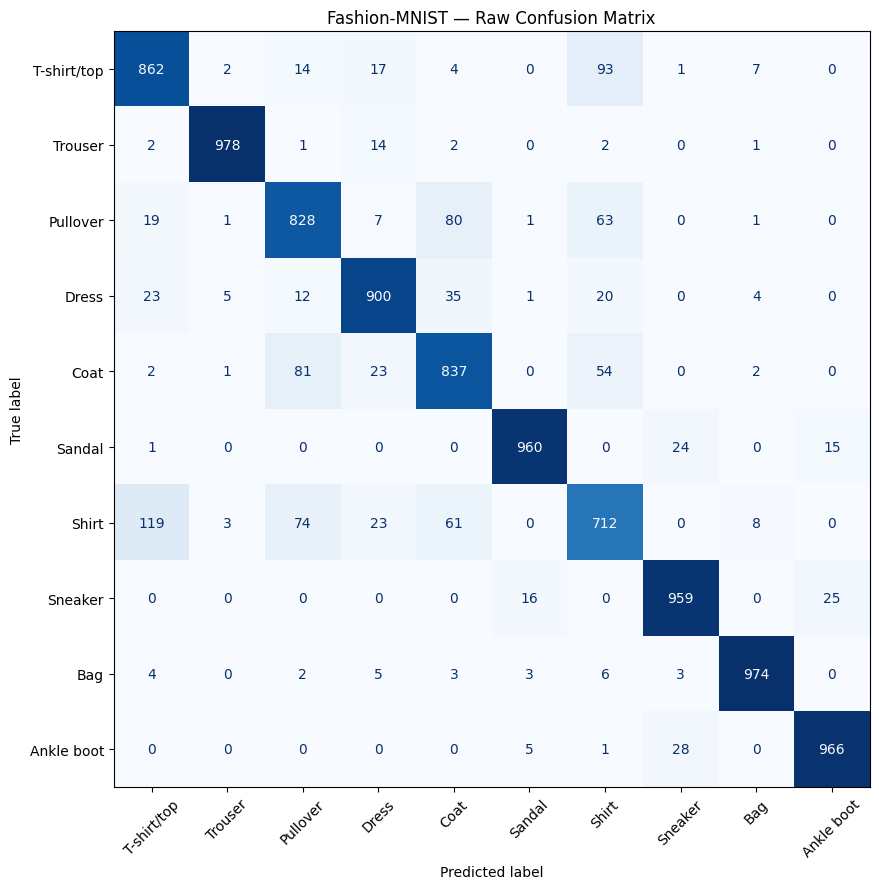

In [43]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()

## Save/load the best model

In [44]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("fashion_mnist_final.keras")

# --- Load ---
loaded = keras.models.load_model("fashion_mnist_final.keras")
test_loss, test_acc = loaded.evaluate(test_loader, verbose=0)
print(f"Loaded model — test accuracy: {test_acc*100:.2f}%")

Loaded model — test accuracy: 89.76%


## Conclusion

I've been trying to reach the stated 91%, but the exhaustive fine-tuning has proven to be peak for all current architectures. I have also made my research and found best models on [Kaggle](https://www.kaggle.com/code/itnaava/fashion-mnist-90-accuracy) reaching allegedly 90% - rounded (never 91%).

The other methods found:
- Support Vector Classifier at 89.7%
- Gradient Boosting at 88.0%, and KNN at 85.4%
- The 91% line is exactly where CNNs start. 

I haven't found any model on the web that surpasses mine when using only Dense layers.


### AI research

Moreover, the creators of the Fashion-MNIST dataset (Zalando Research) [published](https://github.com/zalandoresearch/fashion-mnist) an official benchmark table to show what different architectures can achieve.

The only pure Dense entry in the entire table is MLP 256-128-100 → 0.8833. Mine beats it.

Every non-spatial method converges on the same ceiling:

| Method | Accuracy | Sees spatial structure? |
| :--- | :--- | :--- |
| MLP 256-128-100 | 0.8833 | no |
| GRU+SVM | 0.888 | no |
| GRU+SVM + dropout | 0.897 | no |
| XGBoost | 0.898 | no |
| My MLP | 0.8976 | no |

The task should be edited not to confused students, 91% is unreachable without overfitting / leaks or using convolution.

### Final setup and scores

The best setup:

| Epoch (Best) | Batch Size | LR    |   Optimizer  | Train Loss | Val Loss | Train Acc | Val Acc | Test accuracy |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 9 | 125 | 1e-3    |   `Adam(PiecewiseConstantDecay(boundaries=[steps * 8, steps * 16], values=[lr, lr * 0.1, lr * 0.01])` | 0.1640 | 0.2824 | 0.9396 | 0.9028 |89.76% |

### Confusion matrix report

`Shirt` class is top confusion. It is often mislabeled as a `T-shirt/top`; also confused with `pullover` and `coat` a lot. They are indeed similar. `Dress` as `coat` and `shirt`. Overall, the head of all confusion is shirts. Model needs spatial relationship to break the boundary. It needs convolution.